# M1: load and visualize the behavioral (manual match) data

`PLANbeh.md` M1: the manual/behavioral task asks each participant to click a
(red, green) point that looks isoluminant to them -- the same physical
judgment the SSVEP grid experiment probes electrophysiologically, but
reported directly. Raw data: `/home/sebas/data/manualTest/behavioral_table.csv`
(read in place), one row per click, already tidy -- 47 subjects, up to 3
sessions, ~15-25 clicks per session. `group` comes from the raw file's
`PartType` (1=HC, 2=CVD, 3=PD, 4=HD); `subgroup` (protan/deutan) is looked up
live from `ssveps/files/metadata.csv`, since these are the same participants
who did the SSVEP experiment.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import loader
import plotting
import comparisons

df = loader.load_behavioral()

# HC = the data's CTR (control) group label -- same categories convention as ssveps
categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'CVD', 'group': 'CVD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

df.groupby(['group', 'subgroup'])['sub_id'].nunique()

group  subgroup
CTR    NA          23
CVD    deutan       7
       protan       8
HD     NA           1
PD     NA           8
Name: sub_id, dtype: int64

## One participant, one session

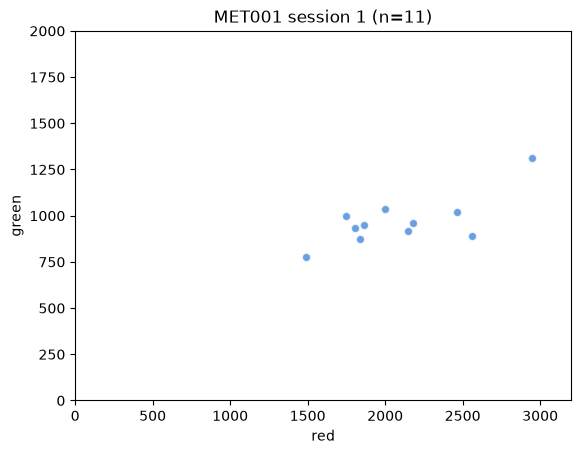

In [2]:
plotting.plot_subject_session(df, 'MET001', 1);

## One participant, multiple sessions (each its own color)

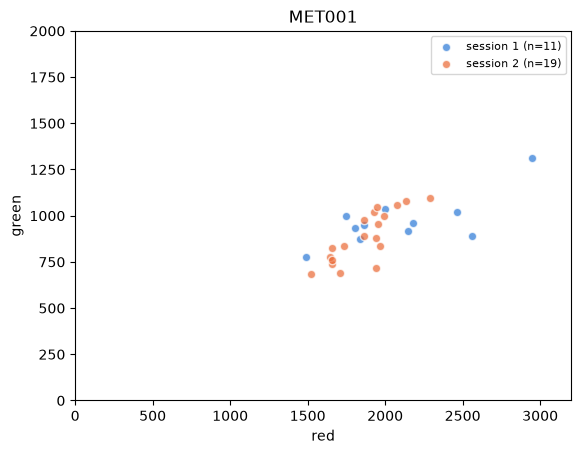

In [3]:
plotting.plot_subject_sessions(df, 'MET001');

## One participant, every session pooled into one cloud

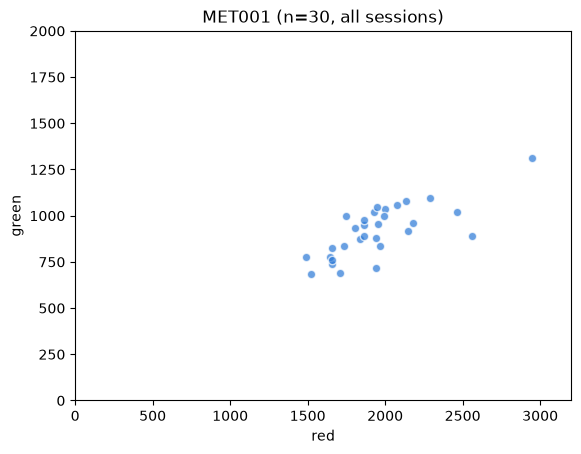

In [4]:
plotting.plot_subject_cloud(df, 'MET001');

## A group/subgroup, one panel per participant
Wrapped to at most 5 panels per row.

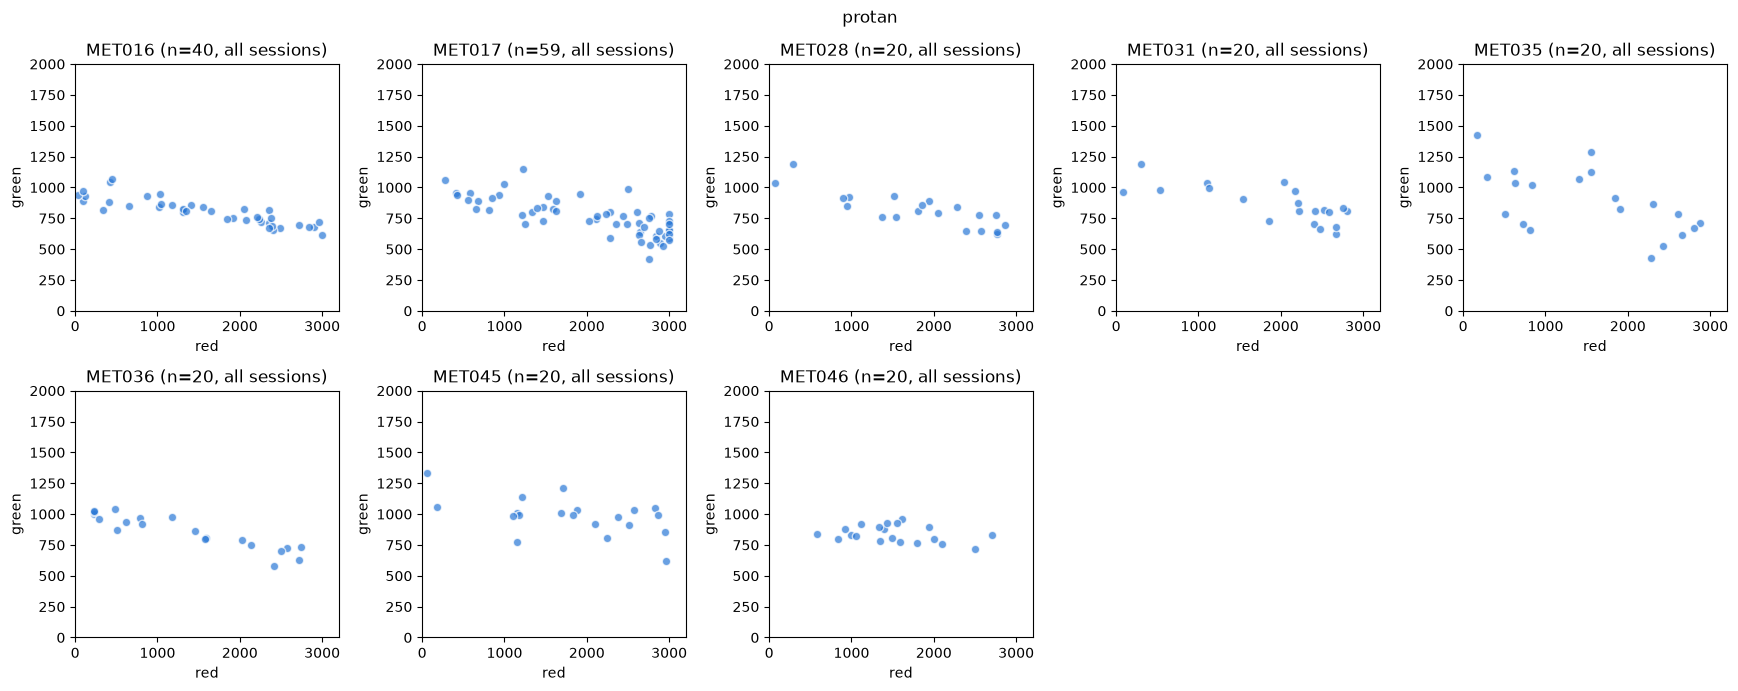

In [5]:
plotting.plot_subjects_grid(df, subgroup='protan');

## A group/subgroup, all subjects pooled onto one plot

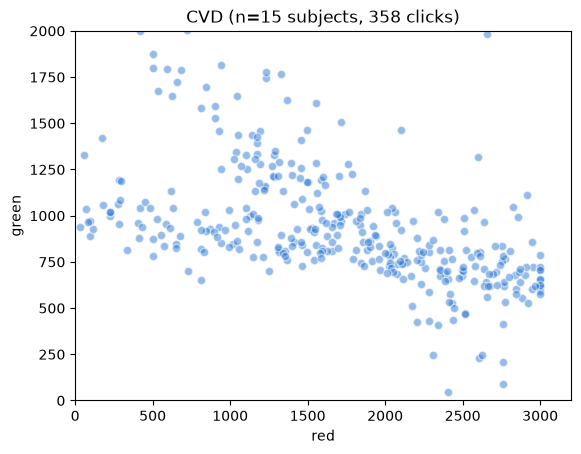

In [6]:
plotting.plot_subjects_pooled(df, group='CVD');

## An arbitrary hand-picked set of participants
`sub_ids` works the same way in both `plot_subjects_grid` and
`plot_subjects_pooled` as `group`/`subgroup` -- pass an explicit list instead
of a filter to look at any subset together, e.g. a few subjects flagged as
outliers, or a hand-picked comparison set that doesn't correspond to a single
group.

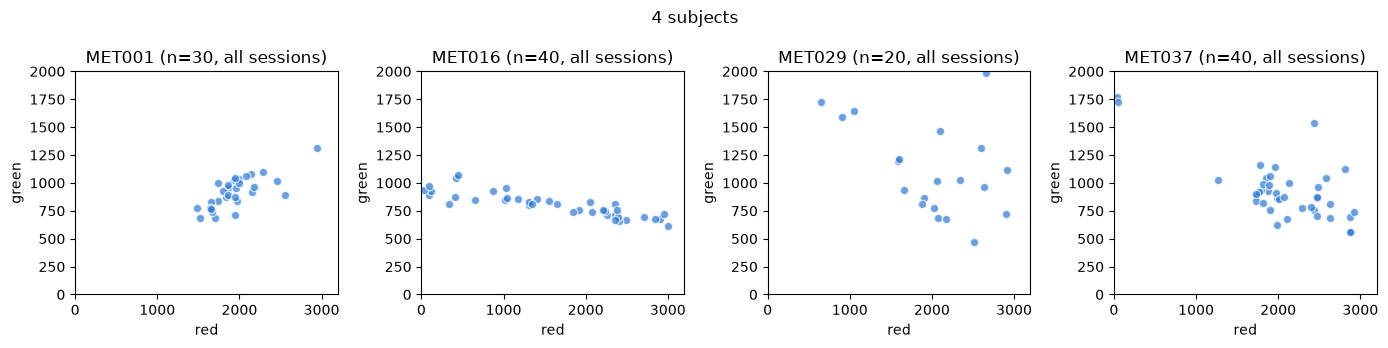

In [7]:
some_subjects = ['MET001', 'MET016', 'MET029', 'MET037']
plotting.plot_subjects_grid(df, sub_ids=some_subjects);

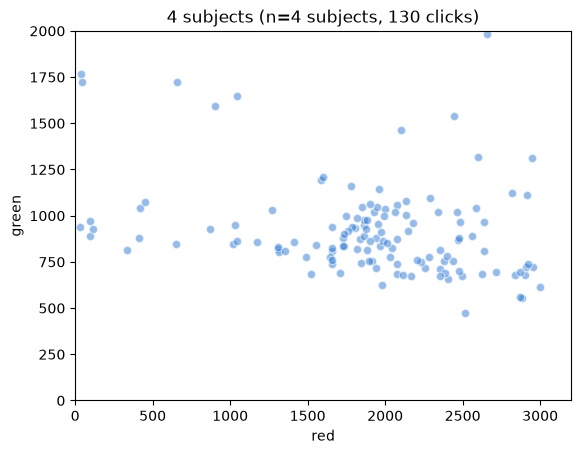

In [8]:
plotting.plot_subjects_pooled(df, sub_ids=some_subjects);

## Groups side by side
HC, PD, CVD, protan, deutan (HD excluded, n=1, same convention as
`ssveps/notebooks/04_distributions.ipynb`).

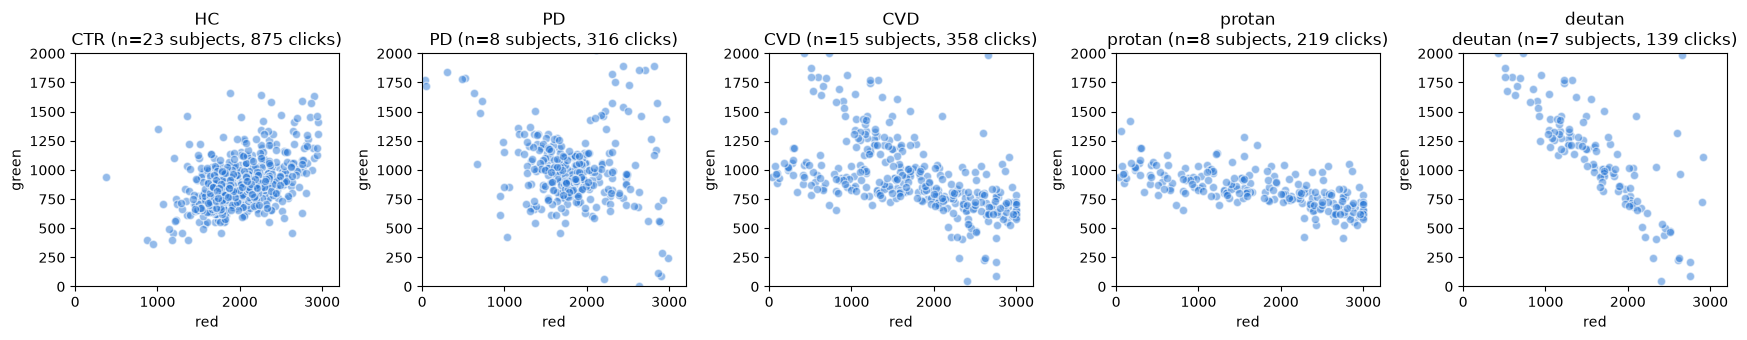

In [9]:
plotting.plot_groups_side_by_side(df, categories);

Even before any statistics, protan and deutan both show a clear downward
diagonal trend (green falls as red rises) that HC and PD don't show nearly
as strongly -- consistent with a color-confusion line, and a first look at
why the group comparisons below come out as clearly as they do.

## Understanding the Hotelling T² comparisons: why the unit of observation is a parameter

Hotelling's T² is the multivariate version of a two-sample t-test -- instead
of comparing two groups' means on one number, it compares their means on a
*vector* (here, (red, green)), accounting for how the two dimensions
covary. `comparisons.py` uses the `hotelling` package for the actual
statistic rather than a hand-rolled implementation (the project's MATLAB
reference, `beh/templateCode/Hot_Tsqd_2samplesPaired.m`, is the *paired*
one-sample-on-differences version -- a different test, for matched
same-subject comparisons, not what the group-vs-group comparisons below need).

The real design question is what counts as *one observation* feeding into
that test, and `comparisons.group_points`/`compare_groups` take it as a
`unit=` parameter rather than picking one:

- **`unit='subject'`** (default): one row per subject, that subject's own
  mean (red, green) across every click they made. This is the statistically
  independent unit -- one subject's 20 clicks aren't 20 independent draws,
  they're 20 correlated measurements of the same person -- and it's what
  every group-vs-group significance test below uses.
- **`unit='point'`**: every click from every subject in the group, pooled.
  Pseudoreplicated (correlated clicks treated as independent), so its
  p-values are not to be trusted at face value -- but it's the only way to
  see a group's actual point-cloud *shape*, which is exactly what's needed
  for protan/deutan: at n=7-8 subjects there aren't enough subject-means to
  show a distribution's shape at all, while each of those subjects
  contributes 20+ clicks that do.

In [10]:
import numpy as np

x_subject = comparisons.group_points(df, group='CTR', unit='subject')
x_point = comparisons.group_points(df, group='CTR', unit='point')
print(f"HC: {x_subject.shape[0]} subjects (unit='subject') vs {x_point.shape[0]} clicks (unit='point')")

HC: 23 subjects (unit='subject') vs 875 clicks (unit='point')


## The five group comparisons (PLANbeh.md M1), `unit='subject'`

In [11]:
comparison_specs = [
    ('HC vs PD', dict(group1='CTR', group2='PD')),
    ('HC vs CVD', dict(group1='CTR', group2='CVD')),
    ('HC vs protan', dict(group1='CTR', group2='CVD', subgroup2='protan')),
    ('HC vs deutan', dict(group1='CTR', group2='CVD', subgroup2='deutan')),
    ('protan vs deutan', dict(group1='CVD', subgroup1='protan', group2='CVD', subgroup2='deutan')),
]

rows = []
for label, kw in comparison_specs:
    r = comparisons.compare_groups(df, unit='subject', **kw)
    rows.append({'comparison': label, 'n1': r['n1'], 'n2': r['n2'], 't2': r['t2_stat'], 'f': r['f_stat'], 'p_value': r['p_value']})
subject_results = pd.DataFrame(rows)
subject_results

,comparison,n1,n2,t2,f,p_value
0,HC vs PD,23,8,26.840996,12.957722,0.000114
1,HC vs CVD,23,15,24.714352,12.013921,0.000113
2,HC vs protan,23,8,19.720069,9.520033,0.000743
3,HC vs deutan,23,7,38.799718,18.707007,0.000009
4,protan vs deutan,8,7,20.283862,9.361783,0.004223


Every comparison is significant at the subject level, including protan vs.
deutan (p=0.004, n=8 vs 7) -- notably, this behavioral 2D match-point task
separates protan from deutan far more clearly than the SSVEP
`ramp_slope_red` measure did (`ssveps/notebooks/08_cvd_gamut.ipynb`: p=0.44).
That's not a contradiction -- a direct behavioral report of where a color
looks isoluminant is a much more direct measure of the perceptual judgment
than an indirect neural correlate, so a larger effect size here is
plausible, not suspicious. Worth keeping in mind as this project develops
both datasets in parallel: the behavioral task may end up doing some of the
subtyping work the SSVEP measures are still underpowered for.

## The same five comparisons, `unit='point'` -- for reference, not for p-values

In [12]:
rows = []
for label, kw in comparison_specs:
    r = comparisons.compare_groups(df, unit='point', **kw)
    rows.append({'comparison': label, 'n1': r['n1'], 'n2': r['n2'], 't2': r['t2_stat'], 'f': r['f_stat'], 'p_value': r['p_value']})
point_results = pd.DataFrame(rows)
point_results

,comparison,n1,n2,t2,f,p_value
0,HC vs PD,875,316,188.466641,94.154066,1.111975e-38
1,HC vs CVD,875,358,136.127305,68.008361,9.712887e-29
2,HC vs protan,875,219,46.248898,23.103273,1.490116e-10
3,HC vs deutan,875,139,394.980402,197.295053,4.674588e-73
4,protan vs deutan,219,139,134.198061,66.910550,2.246231e-25


Every p-value drops by 10-30+ orders of magnitude relative to the
subject-level table -- not because the effect is actually that much
stronger, but because pooling ~200-900 correlated clicks as if independent
manufactures sample size out of nothing. **Use `unit='subject'` for any
comparison whose p-value or significance will be reported or acted on;
reach for `unit='point'` only to visualize a group's point-cloud shape**
(as in the grid/pooled plots above), never to claim significance.